# 🧪 Practical Exam: Data Mining with Python

**Course:** Data Mining  
**Format:** Hands-on (Jupyter Notebook)  
**Time Limit:** _Instructor to specify_  
**Dataset:** `sales_data.csv`  
**Context:** บริษัท “**ShopSmart**” เป็นร้านค้าปลีกออนไลน์ที่จำหน่ายสินค้าอิเล็กทรอนิกส์และเครื่องใช้ในบ้าน ต้องการใช้ Data Mining เพื่อวิเคราะห์พฤติกรรมของลูกค้าและทำนายยอดใช้จ่ายรวมของลูกค้า
  
**Schema (columns):**
`CustomerID, Age, Gender, ProductCategory, Quantity, Price, TotalSpend, PurchaseDate`

> 🔒 **ข้อกำหนด**: ห้ามลบเซลล์ข้อสอบ แต่สามารถเพิ่มเซลล์ใหม่ได้ใต้แต่ละข้อเพื่อแสดงการทำงานเพิ่มเติม
> 
> 📝 **รูปแบบคำตอบ**: แบบเติมคำ (fill-in) ในส่วน `____` และ/หรือเพิ่มโค้ดของคุณเอง


## คำแนะนำโดยรวม
- ให้รันเซลล์ตามลำดับจากบนลงล่าง
- หากพบ `____` ให้เติมคำสั่ง/พารามิเตอร์ให้ถูกต้อง
- เมื่อเสร็จสิ้นแต่ละตอน ให้รันเพื่อยืนยันว่าไม่มี error
- เซฟไฟล์เป็นชื่อ: `dm_exam_รหัสนักศึกษา.ipynb` ก่อนส่ง

---


---
## ตอนที่ 1: การนำเข้าไลบรารีพื้นฐาน (5 คะแนน)

**โจทย์:** นำเข้าไลบรารีที่จำเป็นสำหรับงาน Data Mining ได้แก่ `pandas`, `numpy`, `matplotlib`, `seaborn`, และโมดูลที่จำเป็นจาก `sklearn`

> เติมคำสั่งในช่องว่างให้ถูกต้อง


In [ ]:
# เติมคำสั่งให้ครบ/ถูกต้อง
import ______ as pd
import ______ as np
import ______.pyplot as plt
import ______ as sns

from sklearn.model_selection import ______
from sklearn.linear_model import ______
from sklearn.neighbors import ______

# ตั้งค่าแสดงกราฟในโน้ตบุ๊ก
%matplotlib inline


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsClassifier

%matplotlib inline

---
## ตอนที่ 2: การนำเข้าข้อมูล (5 คะแนน)

**โจทย์:** อ่านไฟล์ `sales_data.csv` เข้าสู่ตัวแปร `df` และแสดงข้อมูล 5 แถวแรก

> เติมคำสั่งให้ถูกต้อง


In [ ]:
# เติมคำสั่งให้ถูกต้อง
df = pd.______('sales_data.csv')
df.______()  # แสดง 5 แถวแรก


In [23]:

df = pd.read_csv('./datasets/sales_data.csv')
df.head()


,CustomerID,Age,Gender,ProductCategory,Quantity,Price,TotalSpend,PurchaseDate
0,68128,18,Male,Appliances,5,429.23,2360.00,2024-09-05
1,74448,32,Female,Electronics,5,401.40,2003.97,2024-04-14
2,34077,42,Female,Accessories,4,76.47,279.04,2024-04-06
3,42140,61,Male,Home,1,137.14,139.77,2024-02-17
4,95053,52,Male,Electronics,2,163.45,301.99,2024-01-02


---
## ตอนที่ 3: วิเคราะห์ข้อมูลเบื้องต้น (EDA) (10 คะแนน)

**โจทย์:**  
1) แสดงขนาดของข้อมูล (จำนวนแถวและคอลัมน์)  
2) แสดงค่าสถิติเบื้องต้นของ `TotalSpend` เช่น mean, std  
3) ตรวจสอบค่าว่าง (missing) ในแต่ละคอลัมน์


In [24]:
# 1) ขนาดของข้อมูล
df.shape

# 2) ค่าสถิติของ TotalSpend
df['TotalSpend'].describe()

# 3) ตรวจสอบค่าว่าง
df.isnull().sum()


CustomerID         0
Age                0
Gender             0
ProductCategory    0
Quantity           0
Price              0
TotalSpend         0
PurchaseDate       0
dtype: int64

---
## ตอนที่ 4: การสร้างแผนภาพการกระจาย (Scatter Plot) (10 คะแนน)

**โจทย์:** สร้าง scatter plot แสดงความสัมพันธ์ระหว่าง `Age` (แกน x) และ `TotalSpend` (แกน y) ด้วย `seaborn` พร้อมตั้งชื่อกราฟ

> เติมชื่อคอลัมน์ให้ถูกต้อง


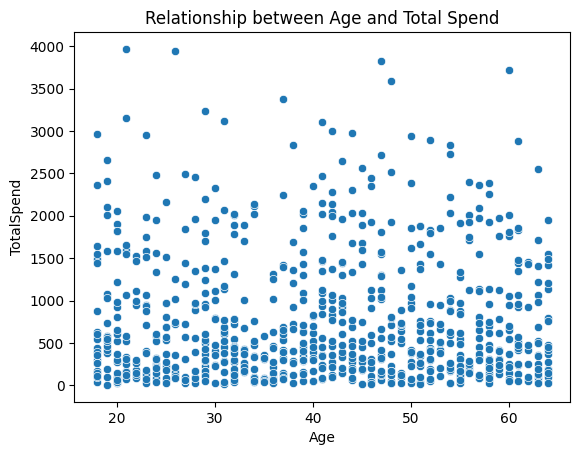

In [27]:
# เติมชื่อคอลัมน์ให้ถูกต้อง
sns.scatterplot(x='Age', y='TotalSpend', data=df)
plt.title('Relationship between Age and Total Spend')
plt.xlabel('Age')
plt.ylabel('TotalSpend')
plt.show()




---
## ตอนที่ 5: การสร้างโมเดล Linear Regression (20 คะแนน)

**โจทย์:**  
- ใช้ตัวแปรอิสระ `Age` และ `Quantity` เพื่อทำนาย `TotalSpend`  
- แบ่งข้อมูลเป็น **train:test = 80:20** (กำหนด `random_state=42`)  
- สร้างและฝึกโมเดล `LinearRegression`


In [28]:
# เตรียมข้อมูล
X = df[['Age', 'Quantity']]
y = df['TotalSpend']

# แบ่งข้อมูล
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# สร้างและฝึกโมเดล Linear Regression
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)


# แสดงค่าสัมประสิทธิ์
print('Coefficients:', model.coef_)
print('Intercept:', model.intercept_)


Coefficients: [  1.47695216 228.93485735]
Intercept: 16.90816698017079


---
## ตอนที่ 6: การสร้างโมเดล K-Nearest Neighbors (KNN) Classification (20 คะแนน)

**โจทย์:**  
- ใช้คุณลักษณะ `Age` และ `TotalSpend` เพื่อจำแนกเพศ (`Gender`)  
- แบ่งข้อมูลเป็น **train:test = 80:20** (`random_state=42`)  
- สร้างและฝึกโมเดล `KNeighborsClassifier(n_neighbors=5)`


In [29]:
# เตรียมข้อมูลสำหรับ KNN
X = df[['Age', 'TotalSpend']]
y = df['Gender']

# แบ่งข้อมูล
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# โมเดล KNN
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)


,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


---
## ตอนที่ 7: การประเมินประสิทธิภาพโมเดล (20 คะแนน)

**โจทย์:**  
- คำนวณค่า **R²** ของโมเดล Linear Regression  
- คำนวณ **Accuracy** ของโมเดล KNN


In [ ]:
# ประเมิน Linear Regression
from sklearn.metrics import r2_score, accuracy_score

y_pred_lr = model.predict(X_test)
r2 = r2_score(y_test, y_pred_lr)
print('R2 =', r2)

# ประเมิน KNN
y_pred_knn = knn.predict(X_test)
acc = accuracy_score(y_test, y_pred_knn)
print('Accuracy =', acc)

ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- TotalSpend
Feature names seen at fit time, yet now missing:
- Quantity


---
## ตอนที่ 8: คำถามเชิงวิเคราะห์ (10 คะแนน)

**โจทย์ (เขียนอธิบายใน Markdown ด้านล่าง):**  
1) ตัวแปรใดมีผลต่อยอดใช้จ่ายของลูกค้ามากที่สุด ตามผลจากโมเดล Linear Regression (อ้างอิงจากค่าสัมประสิทธิ์) และอธิบายเหตุผลที่เป็นไปได้  
2) ประเมินว่าโมเดล KNN เหมาะสมกับโจทย์จำแนกเพศจากคุณลักษณะที่ใช้หรือไม่ มีข้อจำกัดอะไร ควรปรับปรุงอย่างไร


### คำตอบของนักศึกษา
*(พิมพ์คำตอบเป็นย่อหน้าได้ที่นี่ โดยการ `Double Click`)*


---
## (เพิ่มคะแนนพิเศษ) ปรับปรุงโมเดล (สูงสุด 10 คะแนน)

เลือกทำอย่างน้อยหนึ่งข้อ:
- สร้างฟีเจอร์ใหม่ (เช่น `UnitPrice = TotalSpend / Quantity` หรือ `Month` จาก `PurchaseDate`) แล้วประเมินผลซ้ำ
- ปรับ `n_neighbors` ของ KNN และทำกราฟผลความแม่นยำต่อค่า k
- ใช้มาตรฐานข้อมูลด้วย `StandardScaler` ก่อนเทรน KNN แล้วเปรียบเทียบผล


In [39]:
# สร้างฟีเจอร์ใหม่
df['UnitPrice'] = df['TotalSpend'] / df['Quantity']

# ตรวจสอบฟีเจอร์ใหม่
df[['Quantity', 'TotalSpend', 'UnitPrice']].head()

,Quantity,TotalSpend,UnitPrice
0,5,2360.00,472.000
1,5,2003.97,400.794
2,4,279.04,69.760
3,1,139.77,139.770
4,2,301.99,150.995


---
**Prepared for:** Data Mining Practical Exam  
**Generated:** 2025-10-30 11:25:37
